In [1]:
library(tidyverse)
library(vroom)
library(data.table)
library(pheatmap)
library(preprocessCore)
library(purrr)
library(RColorBrewer)
library(ggpubr)

reverse_complement <- function(dna_seq) {
  complement <- c("A" = "T", "T" = "A", "C" = "G", "G" = "C")
  nucleotides <- unlist(strsplit(dna_seq, ""))
  complement_nucleotides <- complement[nucleotides]
  reverse_complement_seq <- paste(rev(complement_nucleotides), collapse = "")
  return(reverse_complement_seq)
}

############# Look at Tau and PSI #################
# Calculate Tau for each gene.
calculate_tau <- function(row){
  # Remove NA values from the row
  non_na_row <- row[!is.na(row)]
  # If the row is empty after removing NAs, return NA
  if (length(non_na_row) < 20) {
    return(NA)
  }
  # Normalize the row by dividing by the max value of the non-NA row
  norm_row <- non_na_row / max(non_na_row)
  # Calculate tau using the number of non-NA values
  tau <- sum(1 - norm_row) / (length(non_na_row) - 1)
  return(tau)
}

# upsilon is the metric for PSI. We add 1 so that values close to 0 will not be inflated.
calculate_upsilon <- function(row) {
  # Remove NA values from the row
  non_na_row <- row[!is.na(row)]
  # If the row is empty after removing NAs, return NA
  if (length(non_na_row) < 20) {
    return(NA)
  }
  # Add 1 to every value in the row.
  non_na_row <- non_na_row + 1
  # Normalize the row by dividing by the max value of the non-NA row
  norm_row <- non_na_row / max(non_na_row)
  # Calculate tau using the number of non-NA values
  tau <- sum(1 - norm_row) / (length(non_na_row) - 1)
  return(tau * 2)
}

output_filepath <- "/mnt/dawnccle2/melange/figures_outputs/fig01"
# Create the output directory if it doesn't exist.
if (!dir.exists(output_filepath)) {
  dir.create(output_filepath, recursive = TRUE)
}
# Now I kinda want to plot the heatmap. 
final_psi_table_filtered <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table.csv")
final_psi_table_filtered <- final_psi_table_filtered %>% 
  filter(!(condition %in% c("K562WT", "K562K700E"))) %>% 
  filter(!(condition %in% c("JHOM1", "RVH421", "KNS60", "OVTOKO"))) %>% 
  mutate(total_count = included_count + skipped_count) %>%
  filter(total_count >= 30) %>%
  mutate(index_offset = paste(index, offset, sep = "__")) %>% 
  separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":") %>% 
  mutate(upstream_offset = as.integer(upstream_offset)) %>% 
  mutate(downstream_offset = as.integer(downstream_offset)) %>%
  mutate(const_offset = as.integer(const_offset)) %>% 
  filter(abs(upstream_offset) != 1 & abs(downstream_offset)!= 1) %>% 
  dplyr::select(-upstream_offset, -downstream_offset, -const_offset) %>% 
  dplyr::select(-index, -mode) %>%
  mutate(PSI = included_count/(included_count + skipped_count))
# Filter out the sequences that are in the blacklist.
blacklist_sequences <- read.csv("/mnt/dawnccle2/melange/process_fastq_250221/03_convert_to_PSI/WT_all_samples_blacklist_sequences.csv")
final_psi_table_filtered <- final_psi_table_filtered %>% 
  filter(!(index_offset %in% blacklist_sequences$index_offset))


dt <- as.data.table(final_psi_table_filtered)

# Compute PSI by condition efficiently
psi_by_condition <- dt[, .(PSI = mean(PSI, na.rm = TRUE), num_rep = .N), by = .(condition, index_offset)][
  num_rep >= 2, .(condition, index_offset, PSI)]  # Filter out groups with <2 replicates

psi_table_pivot <- psi_by_condition %>%
  select(condition, index_offset, PSI) %>%
  pivot_wider(names_from = c(condition), values_from = PSI)

psi_table_pivot_sample <- final_psi_table_filtered %>%
  select(sample, index_offset, PSI) %>%
  pivot_wider(names_from = c(sample), values_from = PSI) 

# Convert to matrix.
psi_table_mat <- as.matrix(psi_table_pivot_sample %>% select(-index_offset))
rownames(psi_table_mat) <- psi_table_pivot_sample$index_offset

# Calculate upsilon for each row. 
upsilon_values <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, calculate_upsilon) %>% 
  as.data.frame() %>% 
  setNames("upsilon")

# Calculate reverse upsilon which is 1-values. 
psi_table_pivot_reverse <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  mutate_all(~ 1 - .)  

# Calculate upsilon for each row.
upsilon_values_reverse <- psi_table_pivot_reverse %>% 
  apply(1, calculate_upsilon) %>% 
  as.data.frame() %>% 
  setNames("upsilon_reverse")


# Calculate tau for each row.
tau_values <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, calculate_tau) %>% 
  as.data.frame() %>% 
  setNames("tau")

# Calculate reverse tau which is 1-values.
tau_values_reverse <- psi_table_pivot_reverse %>% 
  apply(1, calculate_tau) %>% 
  as.data.frame() %>% 
  setNames("tau_reverse")

# Get num NA per row. 
num_na_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) sum(is.na(x))) %>% 
  as.data.frame() %>% 
  setNames("num_na")

# Get min of each row.
min_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) min(x, na.rm = TRUE)) %>% 
  as.data.frame() %>% 
  setNames("min")

# Get max of each row.
max_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) max(x, na.rm = TRUE)) %>% 
  as.data.frame() %>% 
  setNames("max")
# Get mean of each row.
mean_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) mean(x, na.rm = TRUE)) %>% 
  as.data.frame() %>% 
  setNames("mean")

# Get median of each row.
median_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) median(x, na.rm = TRUE)) %>% 
  as.data.frame() %>% 
  setNames("median")

# Get the sample where the PSI is max.
max_sample_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) names(which.max(x))) %>% 
  as.data.frame() %>% 
  setNames("max_sample")

# Get the sample where the PSI is min.
min_sample_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) names(which.min(x))) %>% 
  as.data.frame() %>% 
  setNames("min_sample")

cell_specific_score <- data.frame(index_offset = psi_table_pivot$index_offset, 
                                  upsilon = upsilon_values$upsilon, 
                                  upsilon_reverse = upsilon_values_reverse$upsilon_reverse,
                                  tau = tau_values$tau,
                                  tau_reverse = tau_values_reverse$tau_reverse,
                                  num_na_per_row = num_na_per_row$num_na,
                                  row_max = max_per_row$max,
                                  row_min = min_per_row$min,
                                  row_mean = mean_per_row$mean,
                                  row_median = median_per_row$median,
                                  max_sample = max_sample_per_row$max_sample,
                                  min_sample = min_sample_per_row$min_sample) %>%
  filter(num_na_per_row < 10)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘vroom’


The following objects are masked from ‘package:readr’:

    as.col_spec, col_character, col_date, col_datetime, col_double,
    col_factor, col_guess, col_integer, col_logical, col_number,
    col_skip, col_time, cols, cols_condense, cols_only, date_names,
    date_names_lang, date_names_langs, default_locale, fwf_cols,
    fwf_empty, fwf_positions, fwf_widths, locale, output_column,
    problems, spec



Attaching package: ‘data.table’


The

# Overall Heatmap

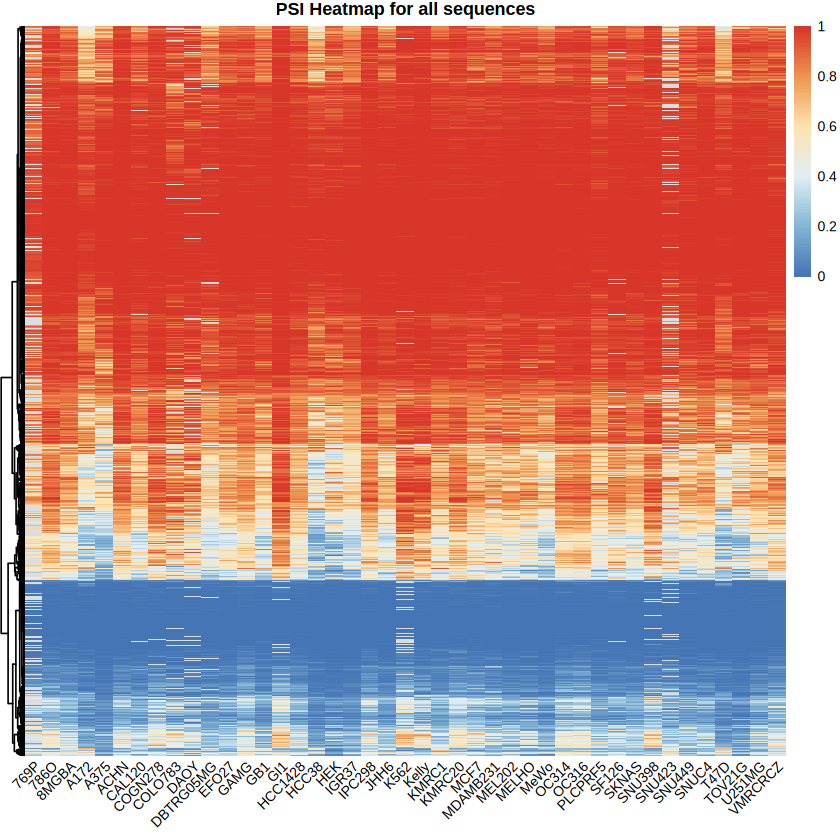

In [2]:
psi_table_pivot_by_condition_mat <- as.matrix(psi_table_pivot %>% select(-index_offset))
rownames(psi_table_pivot_by_condition_mat) <- psi_table_pivot$index_offset
# Filter out rows with >10% NAs.
psi_table_pivot_by_condition_mat <- psi_table_pivot_by_condition_mat[rowMeans(is.na(psi_table_pivot_by_condition_mat)) < 0.1, ]

# color_palette2 <- c("#4575B4", "#80AED1", "#DFF2F6", "#FFE7B8", "#F08944", "#D83629")
color_palette2 <- c(
  "#4575B4",  # deep blue
  "#85B6D6",  # slightly lighter/more even blue
  "#E2EFF2",  # less stark pastel blue
  "#FFE3B0",  # warmer, slightly less saturated yellow
  "#EF9651",  # softer orange
  "#D83629"   # red
)
color_palette2_custom <- colorRampPalette(color_palette2)(100)
color_palette2_custom_rev <- colorRampPalette(rev(color_palette2))(100)

# Plot the PSI_table_pivot big heatmap by condition.
p1 <- pheatmap(psi_table_pivot_by_condition_mat, 
               color = color_palette2_custom, 
               cluster_rows = T,   # Allow clustering for better visualization
               cluster_cols = F,   # Allow clustering for better visualization
                fontsize = 8,         # Increased font size for readability
                border_color = NA,
         main = "PSI Heatmap for all sequences",
         treeheight_row = 10,  # Reduce tree height for better spacing
         treeheight_col = 10,
         show_rownames = FALSE,
         angle_col = 45)      # Cut the tree to create 2 row clusters
ggsave(filename = paste0(output_filepath, "/fig01_PSI_heatmap_all_sequences_overall.pdf"),
       plot = p1,
       width = 24, height = 16, dpi = 300)

# Histogram of global PSI

In [7]:
p1 <- ggplot(psi_by_condition, aes(x = PSI)) + 
  geom_histogram(bins = 50, fill = "#80AED1", color = "black", alpha = 0.8) + 
  labs(title = "Distribution of PSI Values", 
       x = "PSI", 
       y = "Frequency") + 
  theme_minimal(base_size = 14) + 
  theme(plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
        axis.title = element_text(face = "bold"),
        axis.text = element_text(color = "black"),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5))
ggsave(filename = paste0(output_filepath, "/fig01_PSI_distribution.pdf"), plot = p1, width = 8, height = 6, dpi = 300)


# Lineage representation

In [9]:
library(tidyverse)
library(vroom)
library(data.table)
library(Biostrings)
library(ggpointdensity)
library(pheatmap)

all_sample_reps <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table.csv")
# all_sample_reps <- fread("/Volumes/broad_dawnccle/processed_data/latest/all_sample_reps_PSI.csv")
all_samples_wide_PSI <- all_sample_reps %>%
  mutate(index_offset = paste0(index, "__", offset)) %>%
  group_by(condition, index, offset, index_offset) %>%
  summarise(included_count = sum(included_count), skipped_count = sum(skipped_count)) %>%
  ungroup() %>%
  filter((included_count + skipped_count) >= 30) %>%
  separate(offset, into = c("skipped_start_offset", "skipped_end_offset", "downstream_offset"), sep = ":", remove = F) %>%
  mutate(skipped_start_offset = as.integer(skipped_start_offset),
         skipped_end_offset = as.integer(skipped_end_offset),
         downstream_offset = as.integer(downstream_offset)) %>%
  filter(skipped_start_offset < 100 & skipped_end_offset < 100) %>% 
  mutate(PSI = included_count/(included_count + skipped_count)) %>%
  # mutate(PSI = log2((included_count+1)/(skipped_count+1))) %>%
  mutate(condition = toupper(str_extract(condition, "^[^_-]+"))) %>% 
  # Change the DBTR05MG to DBTRG05MG
  mutate(condition = str_replace(condition, "DBTR05MG", "DBTRG05MG")) %>%
  # Change MEWO to MeWo
  mutate(condition = str_replace(condition, "MEWO", "MeWo")) %>%
  # Change JHOM to JHOM1
  mutate(condition = str_replace(condition, "JHOM", "JHOM1")) %>%
  # Remove condition == HEK
  filter(condition != "HEK") %>%
  select(index_offset, condition, PSI) %>%
  pivot_wider(names_from = condition, values_from = PSI, values_fill = NA)

# I'm not using this data, i manually updated it a bit. 
# # Load metadata
# cellline_metadata <- read_csv("/Volumes/broad_dawnccle/melange/data/cellline_data_full_metadata.csv")
# # Get unique conditions
# unique_conditions <- data.frame(StrippedName = unique(all_sample_reps$condition)) 
# # Update StrippedName Kelly to Kelly
# unique_conditions <- unique_conditions %>%
#   mutate(StrippedName = str_replace(StrippedName, "Kelly", "KELLY")) %>%
#   mutate(StrippedName = str_replace(StrippedName, "MEWO", "MeWo"))
# 
# # Filter metadata to only include relevant conditions
# merge_with_metadata <- merge(unique_conditions, cellline_metadata, by = "StrippedName", all.x = TRUE) %>% 
#   select(StrippedName, DepMap_ID, `CCLE_Name.x`, `primary_disease.x`, `Subtype.x`,`Disease Subtype`,`Disease Sub-subtype`,lineage,lineage	lineage_subtype,lineage_sub_subtype, sex, age, Cellosaurus_NCIt_disease, Cellosaurus_NCIt_id, Cellosaurus_issues) %>% 
#   filter(!(StrippedName %in% c("K562K700E", "K562WT"))) %>% 
#   distinct()
# write_csv(merge_with_metadata, "/Volumes/broad_dawnccle/melange/data/FINAL_SET_cellline_metadata_v0.csv")

# Read the updated version v1.
cellline_metadata <- read_csv("/mnt/dawnccle2/melange/data/FINAL_SET_cellline_metadata_v1.csv")
# Prepare summarized data
lineage_counts <- cellline_metadata %>%
  group_by(lineage) %>%
  summarise(n = n_distinct(StrippedName)) %>%
  arrange(desc(n))

# Plot and save
p <- ggplot(lineage_counts, aes(x = reorder(lineage, n), y = n)) +
  geom_bar(stat = "identity", fill = "#52bfd9", color = "black", width = 0.8) +
  coord_flip() +
  theme_minimal(base_size = 14) +
  labs(
    title = "Number of Unique Cell Types per Lineage",
    x = "Lineage",
    y = "Number of Cell Types"
  ) +
  scale_y_continuous(breaks = scales::pretty_breaks(n = 6)) +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    axis.text.y = element_text(size = 12),
    axis.text.x = element_text(size = 12),
    axis.title = element_text(size = 14),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    axis.line = element_line(color = "black")
  )

ggsave(file.path(output_filepath,"fig01_celltypes_by_lineage.pdf"), plot = p, width = 8, height = 6, useDingbats = FALSE)


`summarise()` has grouped output by 'condition', 'index', 'offset'. You can
override using the `.groups` argument.
Rows: 47 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (13): StrippedName, DepMap_ID, CCLE_Name, primary_disease, Subtype, Dise...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
